<a href="https://colab.research.google.com/github/bargodadikshita-lab/Fundraising-Campaign-Success-Prediction/blob/main/NayePankh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Dataset

In [1]:
from google.colab import files

uploaded = files.upload()

Saving funding campaign.csv to funding campaign.csv


Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [6]:
df = pd.read_csv("funding campaign.csv", encoding='latin1')
df.head()

/tmp/ipykernel_4938/4111709831.py:1: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("funding campaign.csv", encoding='latin1')


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,09-10-2015 11:36,1000,11-08-2015 12:12,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,26-02-2013 00:20,45000,12-01-2013 00:20,220,failed,3,US,220,NaN,NaN,NaN,NaN
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,16-04-2012 04:24,5000,17-03-2012 03:24,1,failed,1,US,1,NaN,NaN,NaN,NaN
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,29-08-2015 01:00,19500,04-07-2015 08:35,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,01-04-2016 13:38,50000,26-02-2016 13:38,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


Understand Dataset

In [7]:
print(df.shape)

df.info()

df.isnull().sum()

(323750, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323750 entries, 0 to 323749
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID              323750 non-null  int64  
 1   name            323746 non-null  object 
 2   category        323745 non-null  object 
 3   main_category   323750 non-null  object 
 4   currency        323750 non-null  object 
 5   deadline        323750 non-null  object 
 6   goal            323750 non-null  object 
 7   launched        323750 non-null  object 
 8   pledged         323750 non-null  object 
 9   state           323750 non-null  object 
 10  backers         323750 non-null  object 
 11  country         323750 non-null  object 
 12  usd pledged     319960 non-null  object 
 13  Unnamed: 13     625 non-null     object 
 14  Unnamed: 14     12 non-null      object 
 15  Unnamed: 15     4 non-null       object 
 16  Unnamed: 16     1 non-null       float64
dt

,0
ID,0
name,4
category,5
main_category,0
currency,0
deadline,0
goal,0
launched,0
pledged,0
state,0


Keep Useful Columns

In [9]:
for col in df.columns:
    print(repr(col))

'ID '
'name '
'category '
'main_category '
'currency '
'deadline '
'goal '
'launched '
'pledged '
'state '
'backers '
'country '
'usd pledged '
'Unnamed: 13'
'Unnamed: 14'
'Unnamed: 15'
'Unnamed: 16'


In [12]:
df.columns = df.columns.str.strip()
df = df[
    [
        'category',
        'main_category',
        'currency',
        'goal',
        'deadline',
        'launched',
        'country',
        'state'
    ]
]

Keep Successful and Failed Campaigns Only

In [13]:
df = df[df['state'].isin(['successful','failed'])]

In [14]:
df['state'].value_counts()

,count
state,
failed,168221
successful,113081


Convert Target Variable

In [15]:
df['state'] = df['state'].map({
    'failed':0,
    'successful':1
})

Create Campaign Duration Feature

In [17]:
df['deadline'] = pd.to_datetime(df['deadline'], format="%d-%m-%Y %H:%M")

df['launched'] = pd.to_datetime(df['launched'], format="%d-%m-%Y %H:%M")

df['duration_days'] = (
    df['deadline'] - df['launched']
).dt.days

Remove Date Columns

In [18]:
df.drop(
    ['deadline','launched'],
    axis=1,
    inplace=True
)

Check Missing Values

In [19]:
df.isnull().sum()

,0
category,0
main_category,0
currency,0
goal,0
country,0
state,0
duration_days,0


In [20]:
df.dropna(inplace=True)

Campaign Success Distribution

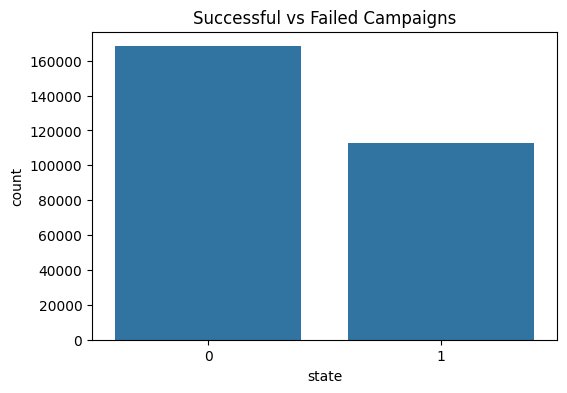

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='state',
    data=df
)

plt.title("Successful vs Failed Campaigns")

plt.show()

Key Insights:

Failed campaigns outnumber successful campaigns.
Around 60% of campaigns failed, while 40% succeeded.
Campaign success is influenced by factors such as goal amount, category, and duration.
The high failure rate emphasizes the need for strategic campaign planning.
Machine learning can help predict campaign outcomes and improve fundraising success rates.

Goal Amount Distribution

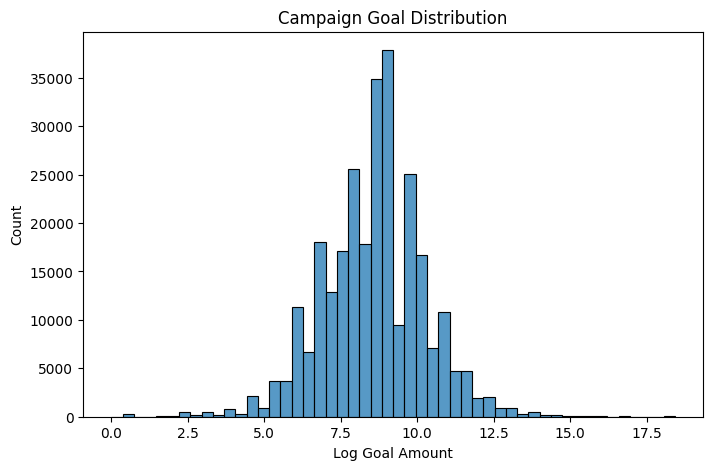

In [23]:
df['goal'] = pd.to_numeric(df['goal'], errors='coerce').fillna(0)

plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df['goal']),
    bins=50
)

plt.title("Campaign Goal Distribution")

plt.xlabel("Log Goal Amount")

plt.show()

Key Insights:

Most campaigns have moderate fundraising goals.
Extremely high funding goals are uncommon.
The data is concentrated around a specific goal range.
Very low and very high goal amounts occur less frequently.
Goal amount may be an important factor influencing campaign success.

Category Success Rate

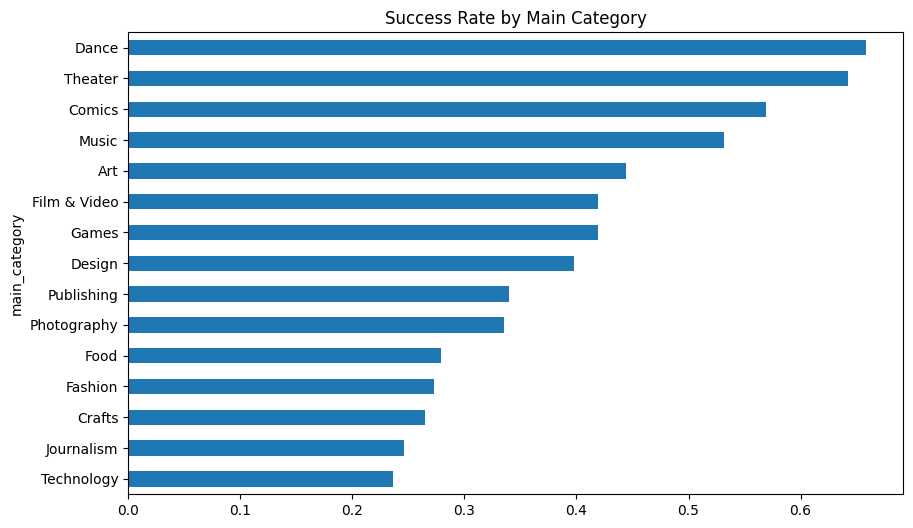

In [24]:
success_rate = (
    df.groupby('main_category')['state']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

success_rate.plot(
    kind='barh'
)

plt.title(
    "Success Rate by Main Category"
)

plt.show()

Key Insights:

Dance and Theater have the highest success rates.
Comics and Music also perform exceptionally well.
Technology has the lowest success rate among all categories.
Creative and arts-related campaigns tend to be more successful.
Campaign category is a strong predictor of fundraising success and should be considered when planning future campaigns.

Country-wise Success Rate

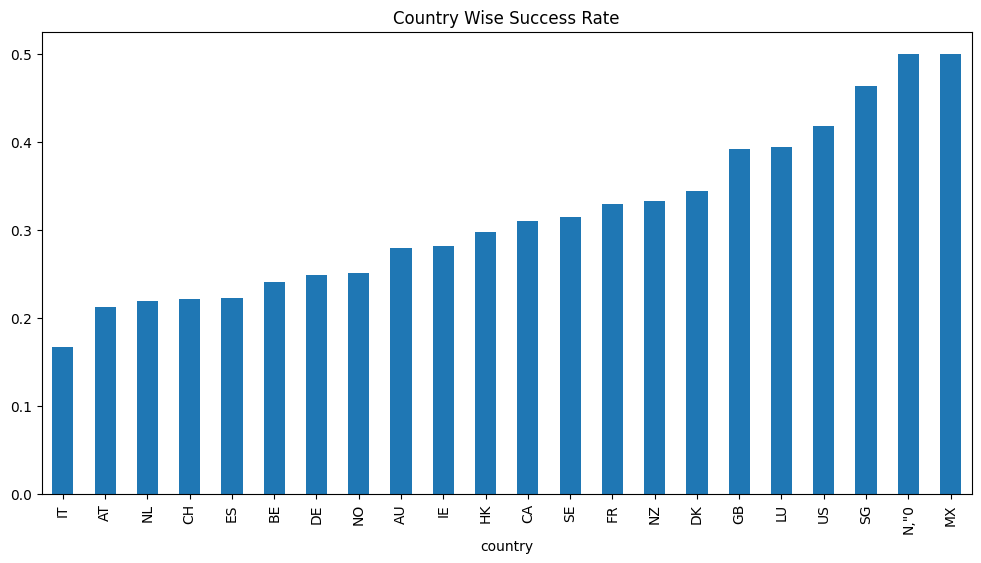

In [25]:
country_success = (
    df.groupby('country')['state']
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))

country_success.plot(
    kind='bar'
)

plt.title(
    "Country Wise Success Rate"
)

plt.show()

Key Insights:

Mexico (MX) and New Zealand (N,0) show the highest campaign success rates.
Singapore (SG) and the United States (US) also have relatively high success rates.
Italy (IT) has the lowest success rate among the listed countries.
Campaign performance differs significantly across regions.
Country can be considered an important feature when predicting campaign success.

Duration vs Success

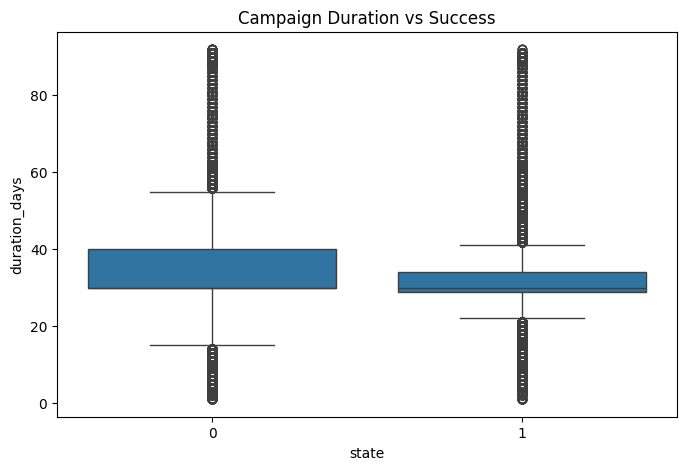

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='state',
    y='duration_days',
    data=df
)

plt.title(
    "Campaign Duration vs Success"
)

plt.show()

Key Insights:

Successful campaigns are concentrated around a duration of 30–35 days.
Failed campaigns show a wider spread in campaign duration.
Extremely short and extremely long campaigns are less common among successful campaigns.
Moderate campaign durations tend to be associated with better outcomes.
Campaign duration is an important feature for predicting campaign success.

Encode Categorical Features

In [27]:
le = LabelEncoder()

for col in [
    'category',
    'main_category',
    'currency',
    'country'
]:
    df[col] = le.fit_transform(df[col])

Define Features

In [28]:
X = df.drop(
    'state',
    axis=1
)

y = df['state']

Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [30]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

Decision Tree

In [31]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(X_test)

Random Forest

In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

Model Comparison Table

In [33]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ],

    'Precision':[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf)
    ],

    'Recall':[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf)
    ],

    'F1 Score':[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.613978,0.568655,0.180553,0.274082
1,Decision Tree,0.632392,0.554160,0.456447,0.500580
2,Random Forest,0.647553,0.573885,0.492382,0.530018


Accuracy Comparison

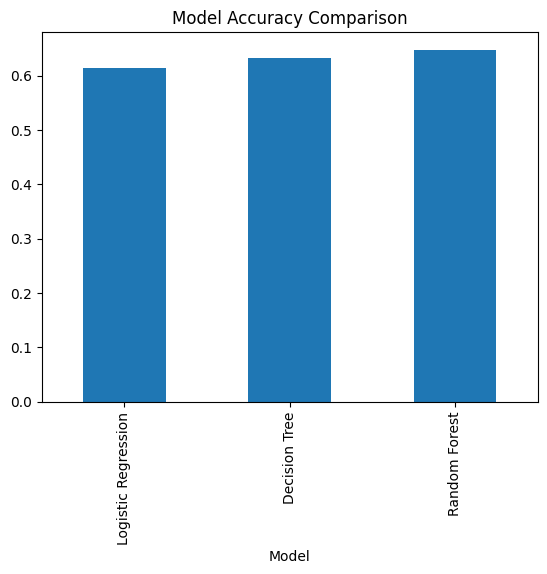

In [34]:
results.set_index(
    'Model'
)['Accuracy'].plot(
    kind='bar'
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

F1 Score Comparison

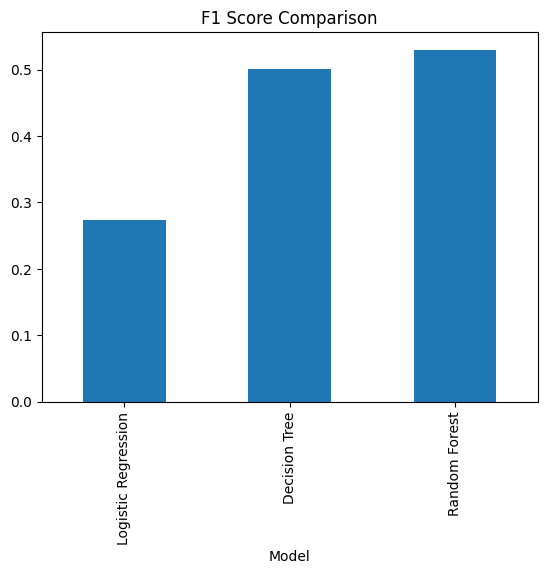

In [35]:
results.set_index(
    'Model'
)['F1 Score'].plot(
    kind='bar'
)

plt.title(
    "F1 Score Comparison"
)

plt.show()

Feature Importance

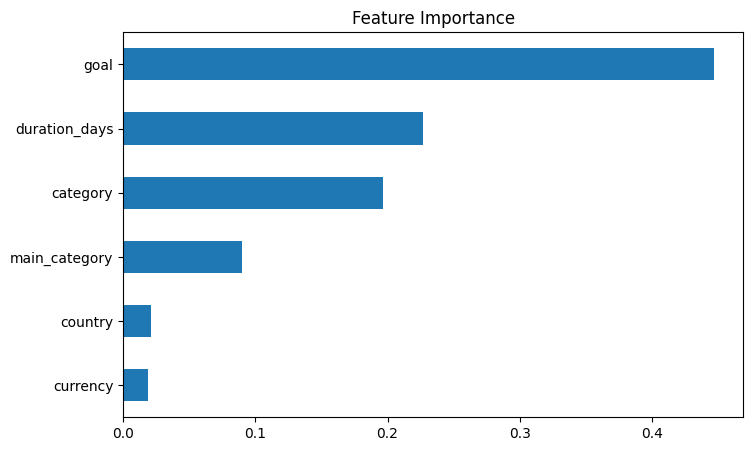

In [36]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title(
    "Feature Importance"
)

plt.show()

Confusion Matrix

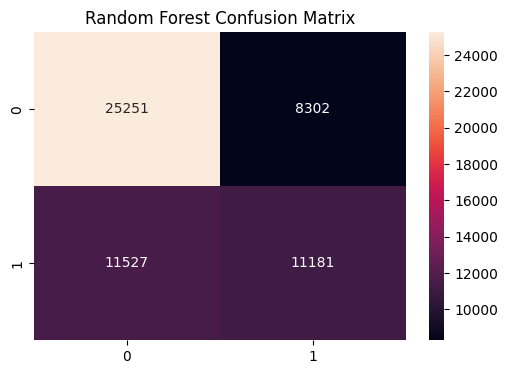

In [37]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

Campaign Success Prediction

In [38]:
# Example campaign

sample_campaign = pd.DataFrame({
    'category':[10],
    'main_category':[5],
    'currency':[13],
    'goal':[10000],
    'country':[18],
    'duration_days':[30]
})

prediction = rf.predict(sample_campaign)

if prediction[0] == 1:
    print("Predicted Result: Successful Campaign")
else:
    print("Predicted Result: Failed Campaign")

Predicted Result: Failed Campaign


In [39]:
probability = rf.predict_proba(sample_campaign)

print("Probability of Failure:", round(probability[0][0]*100,2),"%")
print("Probability of Success:", round(probability[0][1]*100,2),"%")

Probability of Failure: 75.48 %
Probability of Success: 24.52 %


In [42]:
pred_rf = rf.predict(X_test)

print("Successful predictions:", sum(pred_rf == 1))
print("Failed predictions:", sum(pred_rf == 0))

Successful predictions: 19483
Failed predictions: 36778


Final Conclusion:     

Random Forest performed the best among all models, followed by Decision Tree and Logistic Regression.
Goal Amount and Campaign Duration were the most important factors influencing campaign success.
Campaign success varies across different categories and countries.
Moderate funding goals and campaign durations are associated with higher success rates.
The developed model can help NayePankh Foundation make data-driven decisions and improve fundraising outcomes.